# Introduction to Deep Learning with Keras and TensorFlow

This notebook will walk you through the process of creating artificial neural networks and convolutional neural networks for the MNIST dataset.

This notebook is an adadptation of the workbook from Daniel Moser located [here](https://colab.research.google.com/github/AviatorMoser/keras-mnist-tutorial/blob/master/MNIST%20in%20Keras.ipynb). Adaptations include bugfixes, integration of cells for the sake of brewity and addition of tasks.

## The Problem

Our goal is to construct and train an artificial neural network to detect handwritten digits on black and white images. We will do this based on the MNIST dataset.

## Prerequisite Python Modules

First, some software needs to be loaded into the Python environment.

To run this notebook you need to install:
- matplotlib
- numpy
- keras
- tensorflow
- scikit-learn

These should already be installed in Google Colab and can be installed locally using pip install

In [6]:
!pip3 install scikit-learn

In [1]:
import numpy as np                   # advanced math library
import matplotlib.pyplot as plt      # MATLAB like plotting routines
import random                        # for generating random numbers

from keras.datasets import mnist     # MNIST dataset is included in Keras
from keras.models import Sequential  # Model type to be used

from keras.layers import Dense, Dropout, Activation # Types of layers to be used in our model
import keras.utils as np_utils                         # NumPy related tools

from sklearn.metrics import confusion_matrix


## The Dataset

The MNIST dataset is conveniently bundled within Keras, and we can easily load and analyze it. As we can see below, there are 60000 training samples and 10000 test samples. Each sample is a 28 x 28 image.

In [2]:
# The MNIST data is split between 60,000 28 x 28 pixel training images and 10,000 28 x 28 pixel images
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


Using matplotlib, we can plot some sample images.

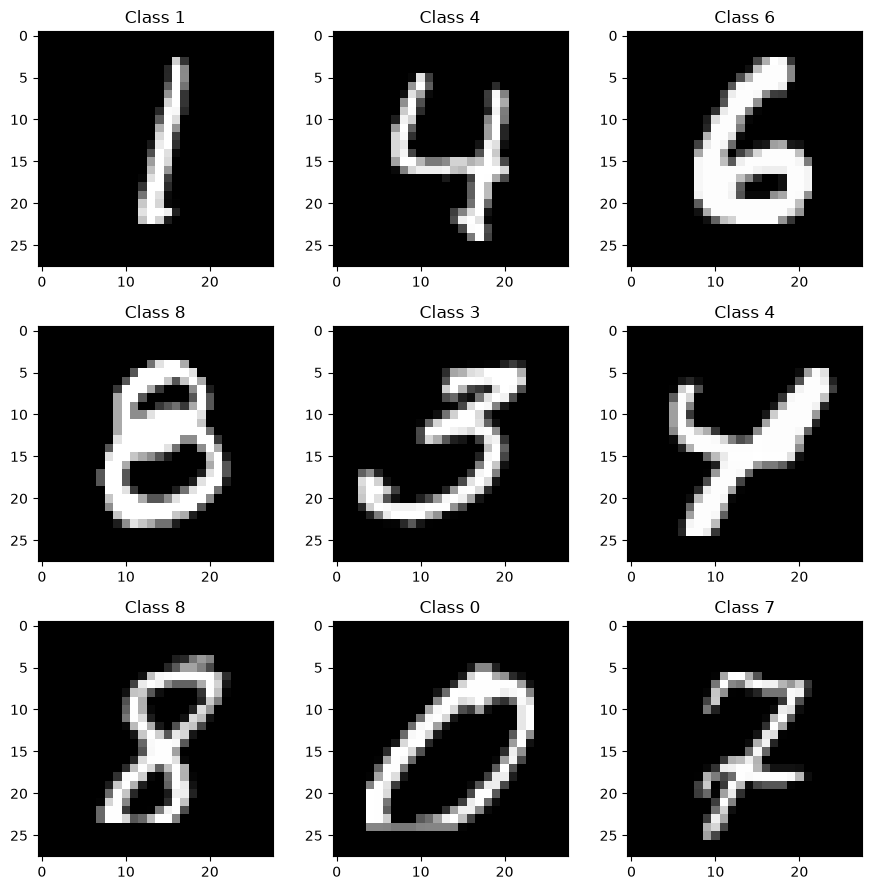

In [3]:
plt.rcParams['figure.figsize'] = (9,9) # Make the figures a bit bigger

for i in range(9):
    plt.subplot(3,3,i+1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap='gray', interpolation='none')
    plt.title("Class {}".format(y_train[num]))

plt.tight_layout()

Let's examine a single image a little closer, and print out the array representing the last digit from the previous cell.

In [4]:
# just a little function for pretty printing a matrix
def matprint(mat, fmt="g"):
    col_maxes = [max([len(("{:"+fmt+"}").format(x)) for x in col]) for col in mat.T]
    for x in mat:
        for i, y in enumerate(x):
            print(("{:"+str(col_maxes[i])+fmt+"}").format(y), end="  ")
        print("")

# now print!
matprint(X_train[num])

0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    0    0    0    0    0    0    0    0    0    0    0   0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0    3  167  254  255  176   83    0    0    0    0    0   0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    0  117  254  135  123  224  252  241  241  181  152  202  56  0  0  0  0  0  0  
0  0  0  0  0  0  0  0   0    5  198  145    1    0   14   37  116  116  116  249  243  38  0  0  0  0  0  0  
0

Each pixel is an 8-bit integer from 0-255. 0 is full black, while 255 is full white. This is what we call a single-channel pixel. It's called monochrome.

*Fun-fact! Your computer screen has three channels for each pixel: red, green, blue. Each of these channels also likely takes an 8-bit integer. 3 channels -- 24 bits total -- 16,777,216 possible colors!*

# Artificial Neural Networks

The first model we will try is a fully connected artificial neural network. Before we define and train this model we have to restructure our data to fit the input and output of this model.

## Data Formatting

Artificial Neural Networks expect their input to be vectors. This means we will convert the 28 x 28 matrix into a 784-length vector. Each image needs to be reshaped (also called flattened) into a vector.

We'll also normalize the inputs to be in the range [0-1] rather than [0-255]. Normalizing inputs is generally recommended, so that any additional dimensions (for other network architectures) are of the same scale.

We also modify our classes (unique digits) to be in the one-hot format, i.e., a vector of numbers where each number represents one class.

In [5]:
X_train = X_train.reshape(60000, 784) # reshape 60,000 28 x 28 matrices into 60,000 784-length vectors.
X_test = X_test.reshape(10000, 784)   # reshape 10,000 28 x 28 matrices into 10,000 784-length vectors.

X_train = X_train.astype('float32')   # change integers to 32-bit floating point numbers
X_test = X_test.astype('float32')

X_train /= 255                        # normalize each value for each pixel for the entire vector for each input
X_test /= 255

nb_classes = 10                       # number of unique digits

Y_train = np_utils.to_categorical(y_train, nb_classes) # reshape output using one-hot encoding
Y_test = np_utils.to_categorical(y_test, nb_classes)

print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)
print("Training output shape", Y_train.shape)
print("Testing output shape", Y_test.shape)

Training matrix shape (60000, 784)
Testing matrix shape (10000, 784)
Training output shape (60000, 10)
Testing output shape (10000, 10)


## Building a 3-layer fully connected network (FCN)


Next we build a fully connected neural network with the following dimensions:

- Input: 784
- 1: Fully Connected Layer - 512 Neurons
- 2: Fully Connected Layer - 512 Neurons
- Output: 10 Neurons

We will compile the model using the Adam optimizer using categorical cross entropy as loss metric.

In [6]:
# The Sequential model is a linear stack of layers and is very common.

model = Sequential()

# 1st layer
model.add(Dense(512, input_shape=(784,))) #(784,) is not a typo -- that represents a 784 length vector!
model.add(Activation('relu'))

# 2nd layer
model.add(Dense(512))
model.add(Activation('relu'))

#output layer
model.add(Dense(10))
model.add(Activation('softmax'))

model.summary()

# Let's use the Adam optimizer for learning
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/Users/max.pinkert/Documents/GitHub/portfolio/.venv-mnist/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## Train the model!

The batch size determines over how much data per step is used to compute the loss function, gradients, and back propagation. Large batch sizes allow the network to complete it's training faster; however, there are other factors beyond training speed to consider.

Too large of a batch size smoothes the local minima of the loss function, causing the optimizer to settle in one because it thinks it found the global minimum.

Too small of a batch size creates a very noisy loss function, and the optimizer may never find the global minimum.

So a good batch size may take some trial and error to find!

In [7]:
model.fit(X_train, Y_train,
          batch_size=128, epochs=5,
          verbose=1)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9359 - loss: 0.2154
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9752 - loss: 0.0799
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9837 - loss: 0.0516
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0346
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9906 - loss: 0.0282


The two numbers, in order, represent the value of the loss function of the network on the training set, and the overall accuracy of the network on the training data. But how does it do on data it did not train on?

## Evaluate Model

Next we evaluate how well the model is working.
We'll evaluate based on the test set to have an unbiased benchmark of our model.

We'll also plot a confusion matrix to inspect which classes are confused with others.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9783 - loss: 0.0757
Test score: 0.0756714716553688
Test accuracy: 0.9782999753952026
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step


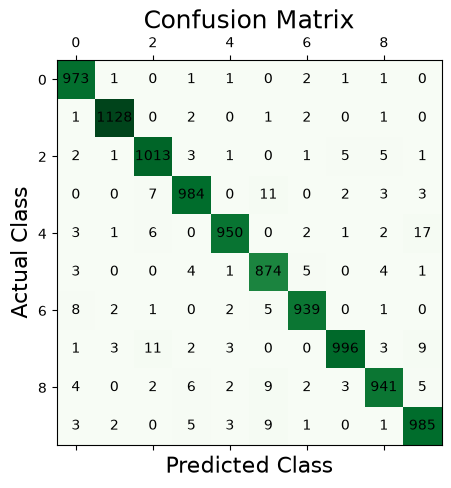

In [8]:
# print test score
score = model.evaluate(X_test, Y_test)
print('Test score:', score[0])
print('Test accuracy:', score[1])

#calculate confusion matrix
Y_pred = model.predict(X_test)
Y_test_classes = np.argmax(Y_test,axis=1)
Y_pred_classes = np.argmax(Y_pred,axis=1)
cm = confusion_matrix(Y_test_classes, Y_pred_classes)

#create and plot confusion matrix figure content
fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(cm, cmap=plt.cm.Greens)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center')

plt.xlabel('Predicted Class', fontsize=16)
plt.ylabel('Actual Class', fontsize=16)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

## Inspecting the output

It's always a good idea to inspect the output and make sure everything looks sane. Here we'll look at some examples it gets right, and some examples it gets wrong.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step





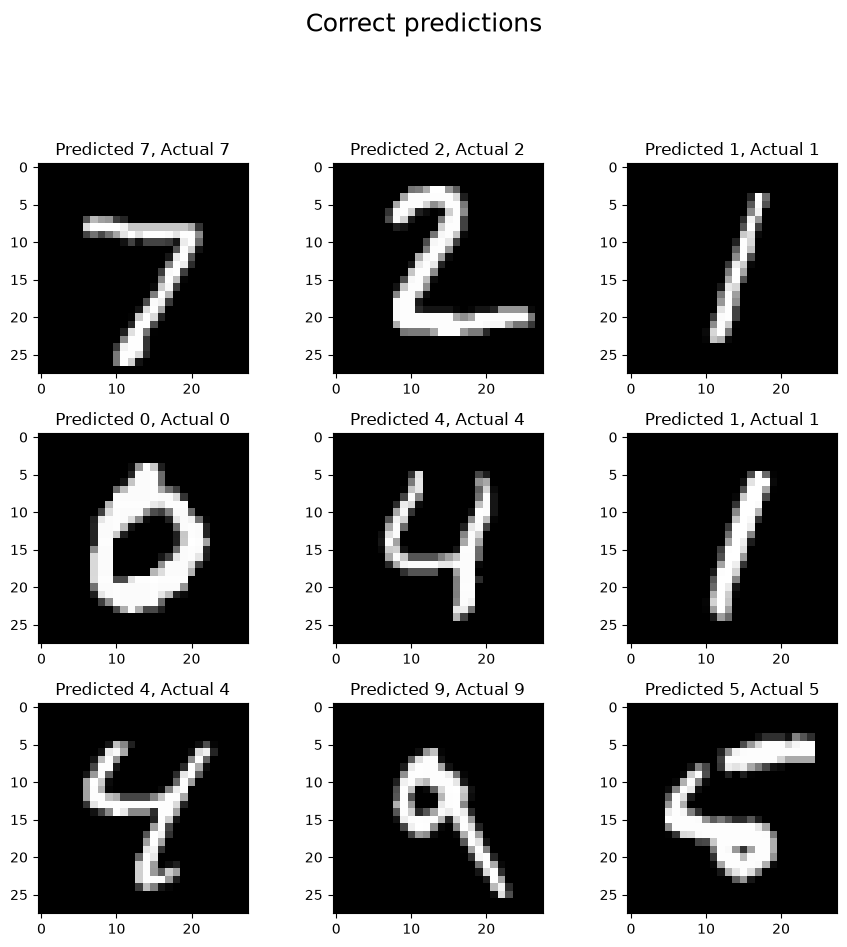

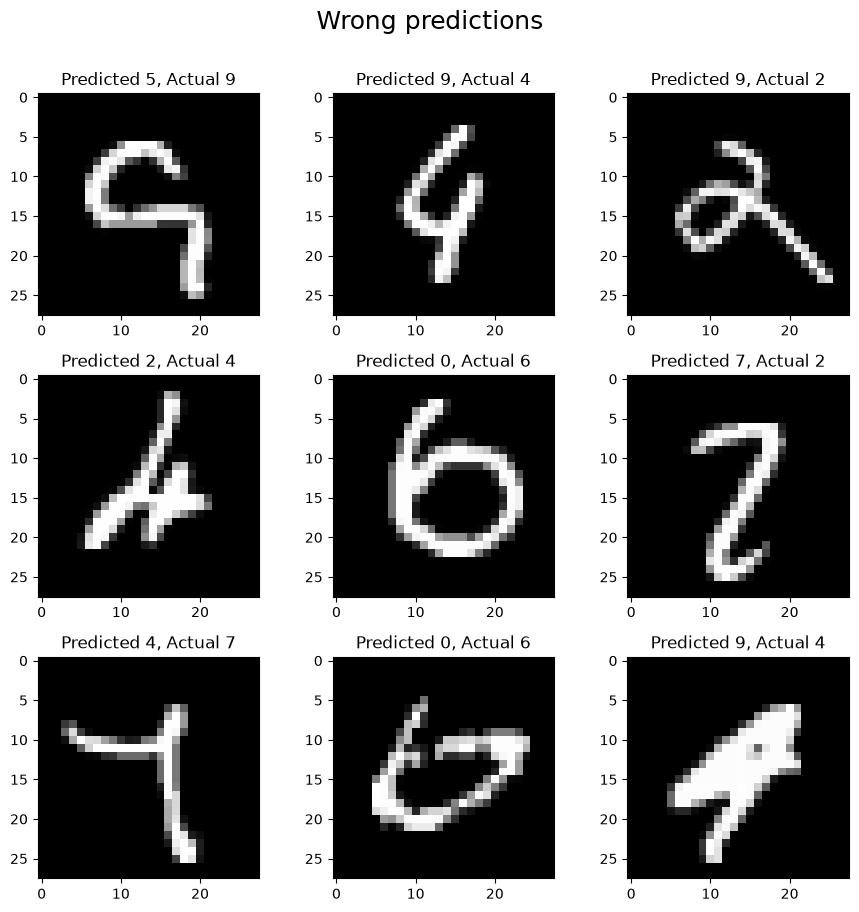

In [9]:
# The predict_classes function outputs the highest probability class
# according to the trained classifier for each input example.

# calculate predicted classes to compare to actual classes
# BUGFIX: updated code to work with current version of keras
y_pred = model.predict(X_test)
predicted_classes = np.argmax(y_pred,axis=1)


# Check which items we got right / wrong
correct_indices = np.nonzero(predicted_classes == y_test)[0]
incorrect_indices = np.nonzero(predicted_classes != y_test)[0]

# plot examples of items we got right
plt.figure()
for i, correct in enumerate(correct_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Actual {}".format(predicted_classes[correct], y_test[correct]))
plt.suptitle('Correct predictions\n', fontsize=18,verticalalignment="bottom")
plt.tight_layout()

print("\n\n")
# plot examples of items we got wrong
plt.figure()
for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[incorrect].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Actual {}".format(predicted_classes[incorrect], y_test[incorrect]))

plt.suptitle('Wrong predictions', fontsize=18,verticalalignment="bottom")
plt.tight_layout()

# Convolutional Neural Networks

Let's try solving the same task using a convolutional neural network. As before we need to do some data formatting first and then can go on to define and train our network.

But before we do that we need some additional imports.

In [10]:
# import some additional tools

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, Flatten
# BUGFIX!
from keras.layers import BatchNormalization

## Data Formatting

Convolutional neural networks can work with two-dimensional input data. This means we need to preprocess our data differently than for artificial neural networks. Let's reload our data and preprocess it. This time we reshape into a 28x28x1 tensor.

In [11]:
# Reload the MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Input Formatting
X_train = X_train.reshape(60000, 28, 28, 1) #add an additional dimension to represent the single-channel
X_test = X_test.reshape(10000, 28, 28, 1)

X_train = X_train.astype('float32')         # change integers to 32-bit floating point numbers
X_test = X_test.astype('float32')

X_train /= 255                              # normalize each value for each pixel for the entire vector for each input
X_test /= 255

# one-hot encoding of output
nb_classes = 10 # number of unique digits
Y_train = np_utils.to_categorical(y_train, nb_classes)
Y_test = np_utils.to_categorical(y_test, nb_classes)

#print data shapes
print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)
print("Training output shape", Y_train.shape)
print("Testing output shape", Y_test.shape)

Training matrix shape (60000, 28, 28, 1)
Testing matrix shape (10000, 28, 28, 1)
Training output shape (60000, 10)
Testing output shape (10000, 10)



## Building a Convolutional Neural Network

Now we build up the convolutional model. The layers here are as follows:
- Input Layer: 28 x 28 x 1 images
- 1: Convolutional Layer - 8 3x3 kernels
- 2: Convolutoinal Layer - 8 3x3 kernels
- 3: Max Pooling Layer   - 2x2
- 4: Convolutional Layer - 16 3x3 kernels
- 5: Convolutional Layer - 16 3x3 kernels
- 6: Max Pooling Layer   - 2x2
- Flattening Layer
- 7: Fully Connected Layer - 64 neurons
- Output Layer: 10 neurons



In [12]:
model = Sequential()                                 # Linear stacking of layers

# Convolution Layer 1
model.add(Conv2D(8, (3, 3), input_shape=(28,28,1))) # 8 different 3x3 kernels -- so 8 feature maps
convLayer01 = Activation('relu')                     # activation
model.add(convLayer01)

# Convolution Layer 2
model.add(Conv2D(8, (3, 3)))                         # 8 different 3x3 kernels -- so 8 feature maps
model.add(Activation('relu'))                        # activation

convLayer02 = MaxPooling2D(pool_size=(2,2))          # Pool the max values over a 2x2 kernel
model.add(convLayer02)

# Convolution Layer 3
model.add(Conv2D(16,(3, 3)))                         # 16 different 3x3 kernels -- so 16 feature maps
convLayer03 = Activation('relu')                     # activation
model.add(convLayer03)

# Convolution Layer 4
model.add(Conv2D(16, (3, 3)))                        # 16 different 3x3 kernels -- so 16 feature maps
model.add(Activation('relu'))                        # activation

convLayer04 = MaxPooling2D(pool_size=(2,2))          # Pool the max values over a 2x2 kernel
model.add(convLayer04)

# Flatten as prep for fully connected Layer
model.add(Flatten())                                 # Flatten final 4x4x64 output matrix into a 1024-length vector

# Fully Connected Layer 5
model.add(Dense(64))                                # 512 FCN nodes
model.add(Activation('relu'))                        # activation

# Fully Connected Layer 6
model.add(Dense(10))                                 # final 10 FCN nodes
model.add(Activation('softmax'))                     # softmax activation

model.summary()

# we'll use the same optimizer
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/Users/max.pinkert/Documents/GitHub/portfolio/.venv-mnist/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 26, 26, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,250 (83.01 KB)

 Trainable params: 21,250 (83.01 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model!

Now let's train the model.

In [13]:

model.fit(x = X_train, y = Y_train, batch_size= 128, epochs=5, verbose=1)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8973 - loss: 0.3405
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9711 - loss: 0.0961
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9783 - loss: 0.0704
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9820 - loss: 0.0577
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9854 - loss: 0.0474


## Evaluate Model

Next we evaluate how well the model is working.
We'll evaluate based on the test set to have an unbiased benchmark of our model.

We'll also plot a confusion matrix to inspect which classes are confused with others.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9881 - loss: 0.0374
Test score: 0.03744287043809891
Test accuracy: 0.988099992275238
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


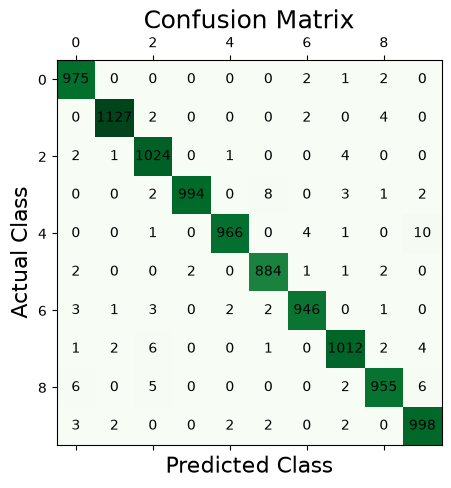

In [14]:
# print score and accuracy of test set
score = model.evaluate(X_test, Y_test)
print('Test score:', score[0])
print('Test accuracy:', score[1])

#calculate confusion matrix
Y_pred = model.predict(X_test)
Y_test_classes = np.argmax(Y_test,axis=1)
Y_pred_classes = np.argmax(Y_pred,axis=1)
cm = confusion_matrix(Y_test_classes, Y_pred_classes)

#create and plot confusion matrix figure content
fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(cm, cmap=plt.cm.Greens)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center')

plt.xlabel('Predicted Class', fontsize=16)
plt.ylabel('Actual Class', fontsize=16)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

## Inspecting the output

It's always a good idea to inspect the output and make sure everything looks sane. Here we'll look at some examples it gets right, and some examples it gets wrong.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step





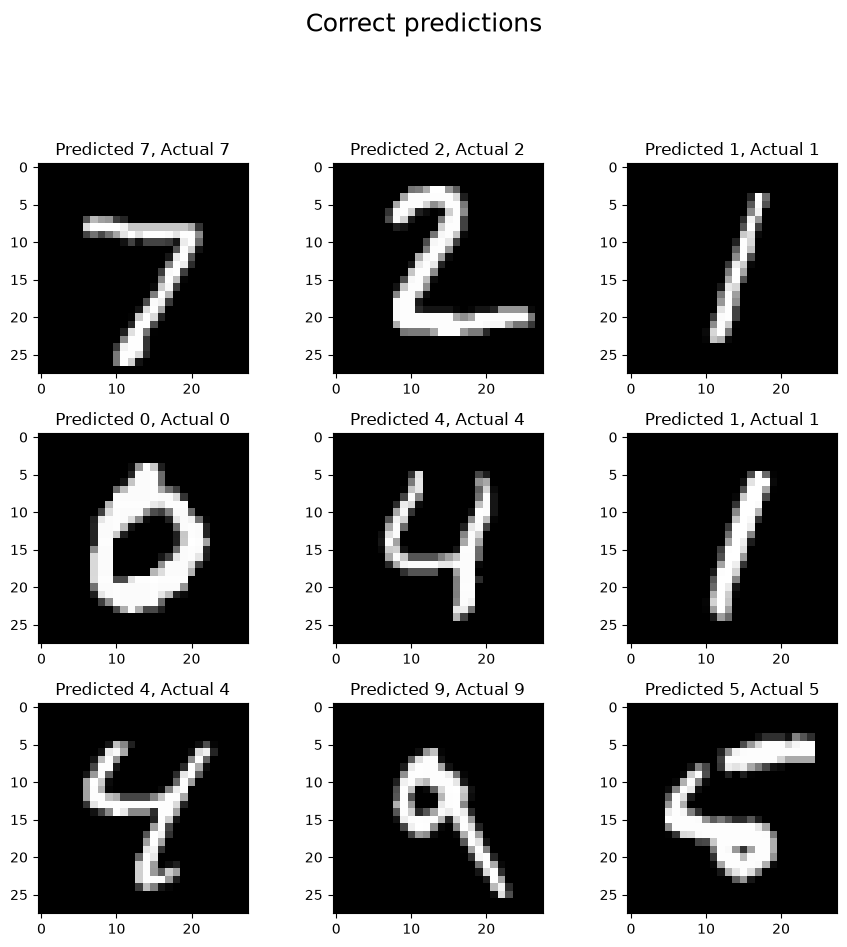

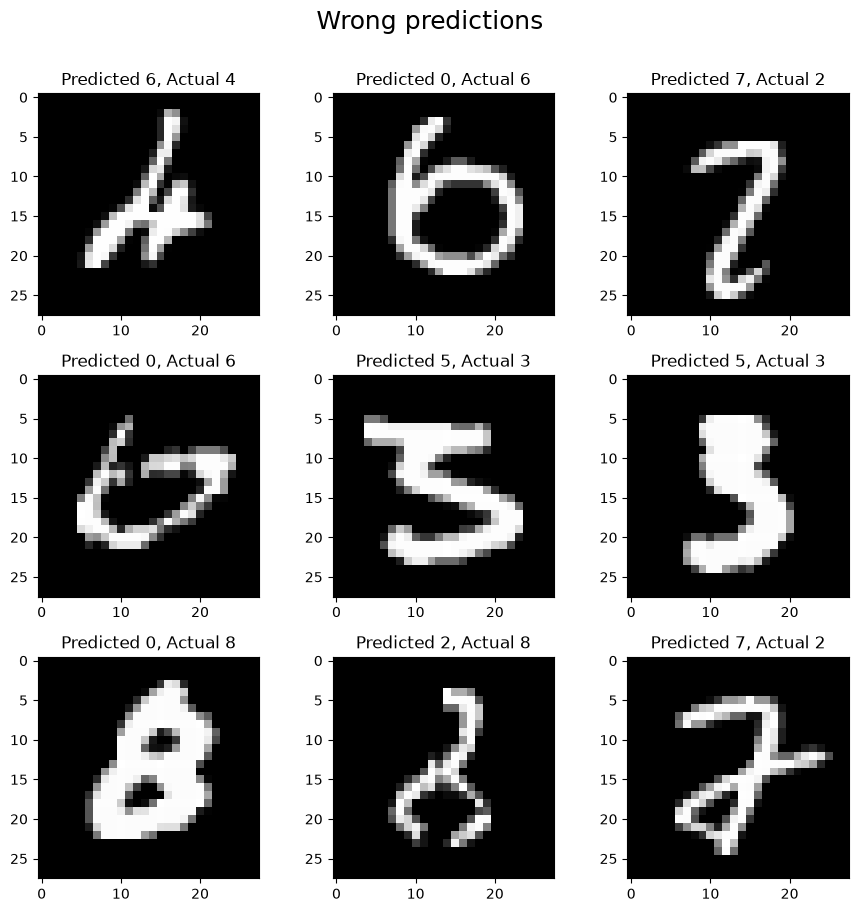

In [15]:
# The predict_classes function outputs the highest probability class
# according to the trained classifier for each input example.

# calculate predicted classes to compare to actual classes
# BUGFIX: updated code to work with current version of keras
y_pred = model.predict(X_test)
predicted_classes = np.argmax(y_pred,axis=1)


# Check which items we got right / wrong
correct_indices = np.nonzero(predicted_classes == y_test)[0]
incorrect_indices = np.nonzero(predicted_classes != y_test)[0]

# plot examples of items we got right
plt.figure()
for i, correct in enumerate(correct_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Actual {}".format(predicted_classes[correct], y_test[correct]))
plt.suptitle('Correct predictions\n', fontsize=18,verticalalignment="bottom")
plt.tight_layout()

print("\n\n")
# plot examples of items we got wrong
plt.figure()
for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[incorrect].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Actual {}".format(predicted_classes[incorrect], y_test[incorrect]))

plt.suptitle('Wrong predictions', fontsize=18,verticalalignment="bottom")
plt.tight_layout()